In [237]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sqlalchemy import create_engine, inspect, text

**Analyst:** Mahathir Islam, w1907417  
**Date:** 17/07/2026

## Data Cleaning & Preprocessing
In this section, we load the raw dataset and standardize metrics to prepare for analytical modeling. This includes converting rates to percentages for better readability and removing null values to ensure statistical accuracy.

In [3]:
df = pd.read_excel(r"C:\Users\DELL\Desktop\Programming\Data analytics\work\world bank\dataAgg.xlsx")

In [4]:
df

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)"
0,Afghanistan,AFG,1957,0.3713,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
1,Afghanistan,AFG,2010,0.0883,0.368077,0.491338,0.035062,2848.5862,0.0,1.479990e+09,0.034794
2,Afghanistan,AFG,2000,0.1317,0.000000,0.297310,0.022298,1617.8264,0.0,4.400000e+05,0.000000
3,Afghanistan,AFG,2011,0.0846,0.379360,0.513897,0.036452,2757.0525,0.0,1.377530e+09,0.034620
4,Afghanistan,AFG,2001,0.1274,0.000000,0.297629,0.022310,1454.1108,0.0,4.200000e+05,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
16830,Zimbabwe,ZWE,2019,0.0511,0.424198,0.671796,0.035774,4993.8438,0.0,1.664000e+07,0.000000
16831,Zimbabwe,ZWE,2020,0.0501,0.424261,0.671664,0.035192,4527.7197,0.0,1.524000e+07,0.000000
16832,Zimbabwe,ZWE,2021,0.0476,0.424381,0.671626,0.034610,4827.0890,NaN,4.257000e+07,0.000000
16833,Zimbabwe,ZWE,2022,0.0460,0.424561,0.671689,0.034618,5036.7610,NaN,4.219000e+07,0.000000


In [5]:
type(df['Year'].iloc[0])

numpy.int64

In [7]:
#df['Year'] = pd.to_datetime(df['Year'],format='mixed').dt.year

In [8]:
df

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)"
0,Afghanistan,AFG,1957,0.3713,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
1,Afghanistan,AFG,2010,0.0883,0.368077,0.491338,0.035062,2848.5862,0.0,1.479990e+09,0.034794
2,Afghanistan,AFG,2000,0.1317,0.000000,0.297310,0.022298,1617.8264,0.0,4.400000e+05,0.000000
3,Afghanistan,AFG,2011,0.0846,0.379360,0.513897,0.036452,2757.0525,0.0,1.377530e+09,0.034620
4,Afghanistan,AFG,2001,0.1274,0.000000,0.297629,0.022310,1454.1108,0.0,4.200000e+05,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
16830,Zimbabwe,ZWE,2019,0.0511,0.424198,0.671796,0.035774,4993.8438,0.0,1.664000e+07,0.000000
16831,Zimbabwe,ZWE,2020,0.0501,0.424261,0.671664,0.035192,4527.7197,0.0,1.524000e+07,0.000000
16832,Zimbabwe,ZWE,2021,0.0476,0.424381,0.671626,0.034610,4827.0890,NaN,4.257000e+07,0.000000
16833,Zimbabwe,ZWE,2022,0.0460,0.424561,0.671689,0.034618,5036.7610,NaN,4.219000e+07,0.000000


In [9]:
type(df['Year'].iloc[0])

numpy.int64

## Year-over-Year (YoY) Growth Analysis
To measure modernization velocity, we calculate the annual growth rates for GDP per capita and infrastructure investment. This helps identify periods of rapid economic acceleration and infrastructure funding spikes in emerging markets like Bangladesh.

In [239]:
df['Under-five mortality rate %'] = np.round(df['Under-five mortality rate %']*100,2)
df['% of people with access to basic hygiene services'] = np.round(df['% of people with access to basic hygiene services']*100,2)
df['% of people with access to basic drinking water services'] = np.round(df['% of people with access to basic drinking water services']*100,2)
df['% of people with access to basic sanitation services'] = np.round(df['% of people with access to basic sanitation services']*100,2)
df['Government expenditure on education, total (% of GDP)'] = np.round(df['Government expenditure on education, total (% of GDP)']*100,2)
df['GDP per capita $'] = np.round(df['GDP per capita $'],2)

In [241]:
df.head()

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)",Investment_Rank
0,Afghanistan,AFG,1957,3713.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,17.0
1,Afghanistan,AFG,2010,883.0,3681.0,4913.0,351.0,2848.59,0.0,1.479990e+09,348.0,24.0
2,Afghanistan,AFG,2000,1317.0,0.0,2973.0,223.0,1617.83,0.0,4.400000e+05,0.0,20.0
3,Afghanistan,AFG,2011,846.0,3794.0,5139.0,365.0,2757.05,0.0,1.377530e+09,346.0,9.0
4,Afghanistan,AFG,2001,1274.0,0.0,2976.0,223.0,1454.11,0.0,4.200000e+05,0.0,4.5


# SQL Push

In [247]:
from sqlalchemy.types import Float, String, Integer, BigInteger
df_sql = df.copy()

#df_sql['Year'] = pd.to_datetime(df_sql['Year']).dt.year

df_sql = df_sql.where(pd.notnull(df_sql), None)

engine = create_engine(
    r'mssql+pyodbc://DESKTOP-LEVIKVU\SQLEXPRESS/WorldBank?driver=ODBC+Driver+17+for+SQL+Server&Trusted_Connection=yes'
)
sql_dtypes = {
    'Country': String(),
    'Code': String(),
    'Year': Integer(), 
    'Under-five mortality rate %': Float(),
    '% of people with access to basic hygiene services': Float(),
    '% of people with access to basic drinking water services': Float(),
    '% of people with access to basic sanitation services': Float(),
    'GDP per capita $': Float(),
    'Money committed to public private partnerships for infrastructure $': Float(), 
    'Total official flows for infrastructure $': Float(), 
    'Government expenditure on education, total (% of GDP)': Float()
}
df_sql.to_sql(
    "BasicHealthandInfr", 
    con=engine, 
    if_exists='replace', 
    index=False, 
    dtype=sql_dtypes,
    method='multi',     
    chunksize=100       
)
print("Data successfully uploaded to SQL Server!")



Data successfully uploaded to SQL Server!


In [25]:
df_sql = df.copy()

In [27]:
df = df_sql

In [29]:
df.head()

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)"
0,Afghanistan,AFG,1957,37.13,0.00,0.00,0.00,NaN,NaN,NaN,0.00
1,Afghanistan,AFG,2010,8.83,36.81,49.13,3.51,2848.59,0.0,1.479990e+09,3.48
2,Afghanistan,AFG,2000,13.17,0.00,29.73,2.23,1617.83,0.0,4.400000e+05,0.00
3,Afghanistan,AFG,2011,8.46,37.94,51.39,3.65,2757.05,0.0,1.377530e+09,3.46
4,Afghanistan,AFG,2001,12.74,0.00,29.76,2.23,1454.11,0.0,4.200000e+05,0.00


In [31]:
df_fil = df[ (df['GDP per capita $'] < 15000) & (df['Year'].between(2015,2026)) & df['GDP per capita $'].notnull() 
    &(df['% of people with access to basic hygiene services'].between(40,80))]

In [33]:
df_fil

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)"
11,Afghanistan,AFG,2015,7.24,42.37,60.52,4.20,2967.69,0.0,628430000.0,3.26
13,Afghanistan,AFG,2016,7.00,43.46,62.82,4.34,2958.79,0.0,525500000.0,4.54
15,Afghanistan,AFG,2017,6.76,44.55,65.14,4.48,2953.00,19820000.0,591640000.0,4.34
25,Afghanistan,AFG,2018,6.54,45.63,67.48,4.61,2902.39,0.0,516720000.0,0.00
26,Afghanistan,AFG,2019,6.33,46.70,69.82,4.75,2927.24,190490000.0,625940000.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...
16830,Zimbabwe,ZWE,2019,5.11,42.42,67.18,3.58,4993.84,0.0,16640000.0,0.00
16831,Zimbabwe,ZWE,2020,5.01,42.43,67.17,3.52,4527.72,0.0,15240000.0,0.00
16832,Zimbabwe,ZWE,2021,4.76,42.44,67.16,3.46,4827.09,NaN,42570000.0,0.00
16833,Zimbabwe,ZWE,2022,4.60,42.46,67.17,3.46,5036.76,NaN,42190000.0,0.00


In [35]:
GrowtRatesDf = df_fil[['Country','Year','Money committed to public private partnerships for infrastructure $','GDP per capita $']]

In [37]:
GrowtRatesDf['YoY % Growth GDP per capita'] = np.round(GrowtRatesDf['GDP per capita $'].pct_change()*100,2)
GrowtRatesDf['YoY % Growth $ Committed'] = np.round(GrowtRatesDf['Money committed to public private partnerships for infrastructure $'].pct_change()*200,2)

C:\Users\DELL\AppData\Local\Temp\ipykernel_10900\3981967984.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  GrowtRatesDf['YoY % Growth GDP per capita'] = np.round(GrowtRatesDf['GDP per capita $'].pct_change()*100,2)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10900\3981967984.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  GrowtRatesDf['YoY % Growth $ Committed'] = np.round(GrowtRatesDf['Money committed to public private partnerships for infrastructure $'].pct_change()*200,2)
C:\Users\DELL\AppData\Local\Temp\ipykernel_10900\3981967984.py:2: Set

#### YoY Growth Rates of GDP per capita and Money committed to public private partnerships 


In [41]:
GrowtRatesDf[GrowtRatesDf['Country']=='Bangladesh'].reset_index()

,index,Country,Year,Money committed to public private partnerships for infrastructure $,GDP per capita $,YoY % Growth GDP per capita,YoY % Growth $ Committed
0,392,Bangladesh,2015,3.235900e+08,5352.71,169.82,139.74
1,396,Bangladesh,2016,1.810900e+08,5682.54,6.16,-88.07
2,398,Bangladesh,2017,6.441300e+08,6005.71,5.69,511.39
3,400,Bangladesh,2018,6.068000e+08,6392.59,6.44,-11.59
4,404,Bangladesh,2019,1.016970e+09,6838.33,6.97,135.19
5,406,Bangladesh,2020,2.948000e+09,7015.20,2.59,379.76
6,408,Bangladesh,2021,NaN,7441.07,6.07,0.00
7,412,Bangladesh,2022,NaN,7888.16,6.01,0.00
8,414,Bangladesh,2023,NaN,8242.40,4.49,0.00


In [43]:
bangladeshGR = GrowtRatesDf[GrowtRatesDf['Country']=='Bangladesh'][1:].reset_index()

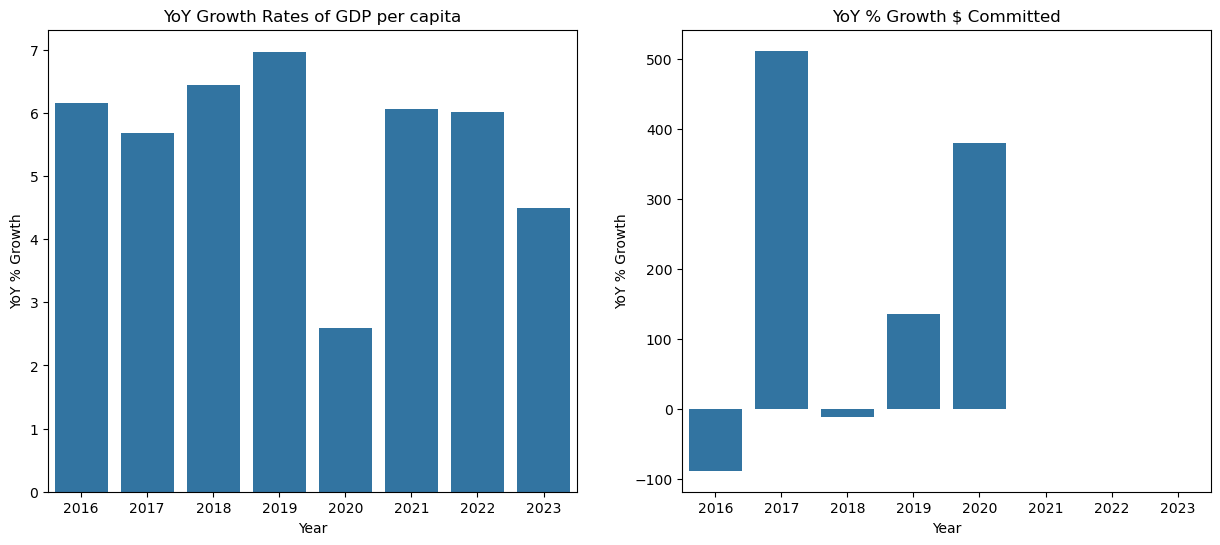

In [81]:

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=bangladeshGR, x='Year', y='YoY % Growth GDP per capita', ax=axes[0])
axes[0].set_title('YoY Growth Rates of GDP per capita')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('YoY % Growth')

sns.barplot(data=bangladeshGR, x='Year', y='YoY % Growth $ Committed', ax=axes[1])
axes[1].set_title('YoY % Growth $ Committed')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('YoY % Growth')

plt.show()

#### Ranking Emerging Markets by their Total Infrastructure Investment


In [102]:
df_rem = df_fil.groupby('Country',as_index=False).agg({'Money committed to public private partnerships for infrastructure $':'sum'})

In [109]:
df_rem = df_rem.rename(columns={'Money committed to public private partnerships for infrastructure $':'Total_Infra_Investement'})
df_rem.head()


,Country,Total_Infra_Investement
0,Afghanistan,2.103100e+08
1,Bangladesh,5.720580e+09
2,Cambodia,1.333060e+09
3,Cape Verde,2.500000e+07
4,Congo,0.000000e+00


In [117]:
df_rem['Investment_Rank'] = df_rem['Total_Infra_Investement'].rank()

In [145]:
df_rem.sort_values('Total_Infra_Investement',ascending=False)

,Country,Total_Infra_Investement,Investment_Rank
9,India,3.787105e+10,29.0
10,Indonesia,3.270499e+10,28.0
20,Pakistan,1.548308e+10,27.0
22,Philippines,1.400968e+10,26.0
25,South Africa,1.088412e+10,25.0
1,Bangladesh,5.720580e+09,24.0
14,Laos,4.828530e+09,23.0
6,Ghana,4.548250e+09,22.0
17,Myanmar,2.559340e+09,21.0
2,Cambodia,1.333060e+09,20.0


## Rolling Averages for Infrastructure
Infrastructure spending is inherently volatile. By applying a **5-year moving average**, we smooth out noise to reveal the underlying long-term investment trends rather than focusing on isolated annual fluctuations.

In [165]:
RAIdf = df_fil.sort_values(by=['Country', 'Year'])

# min_periods=1 ensures it still calculates for the first 1, 2, 3, and 4 years before it reaches a full 5 years
RAIdf['5_Year_Moving_Average'] = (
    RAIdf.groupby('Country')['Money committed to public private partnerships for infrastructure $']
    .transform(lambda x: x.rolling(window=5, min_periods=1).mean().round(2))
)

In [167]:
RAIdf[df_fil['% of people with access to basic hygiene services'].between(40,70)]

,Country,Code,Year,Under-five mortality rate %,% of people with access to basic hygiene services,% of people with access to basic drinking water services,% of people with access to basic sanitation services,GDP per capita $,Money committed to public private partnerships for infrastructure $,Total official flows for infrastructure $,"Government expenditure on education, total (% of GDP)",5_Year_Moving_Average
11,Afghanistan,AFG,2015,7.24,42.37,60.52,4.20,2967.69,0.0,628430000.0,3.26,0.00
13,Afghanistan,AFG,2016,7.00,43.46,62.82,4.34,2958.79,0.0,525500000.0,4.54,0.00
15,Afghanistan,AFG,2017,6.76,44.55,65.14,4.48,2953.00,19820000.0,591640000.0,4.34,6606666.67
25,Afghanistan,AFG,2018,6.54,45.63,67.48,4.61,2902.39,0.0,516720000.0,0.00,4955000.00
26,Afghanistan,AFG,2019,6.33,46.70,69.82,4.75,2927.24,190490000.0,625940000.0,0.00,42062000.00
...,...,...,...,...,...,...,...,...,...,...,...,...
16830,Zimbabwe,ZWE,2019,5.11,42.42,67.18,3.58,4993.84,0.0,16640000.0,0.00,13704000.00
16831,Zimbabwe,ZWE,2020,5.01,42.43,67.17,3.52,4527.72,0.0,15240000.0,0.00,13704000.00
16832,Zimbabwe,ZWE,2021,4.76,42.44,67.16,3.46,4827.09,NaN,42570000.0,0.00,17130000.00
16833,Zimbabwe,ZWE,2022,4.60,42.46,67.17,3.46,5036.76,NaN,42190000.0,0.00,0.00


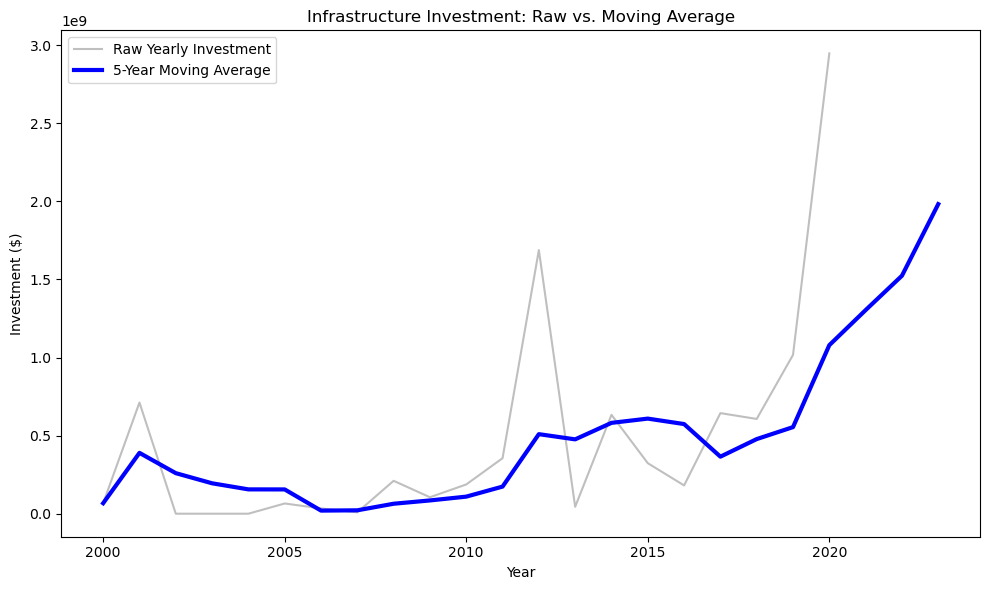

In [171]:
bangladesh_data = df_sql[df_sql['Country'] == 'Bangladesh']

# Set up the plot size
fig, ax = plt.subplots(figsize=(10, 6))

# Plot 1: The Raw Data 
sns.lineplot(
    data=bangladesh_data, 
    x='Year', 
    y='Money committed to public private partnerships for infrastructure $', 
    ax=ax, 
    color='grey', 
    alpha=0.5, 
    label='Raw Yearly Investment'
)

# Plot 2: The 5-Year Moving Average
sns.lineplot(
    data=bangladesh_data, 
    x='Year', 
    y='5_Year_Moving_Average', 
    ax=ax, 
    color='blue', 
    linewidth=3, 
    label='5-Year Moving Average'
)

ax.set_title('Infrastructure Investment: Raw vs. Moving Average')
ax.set_xlabel('Year')
ax.set_ylabel('Investment ($)')
ax.legend()

plt.tight_layout()
plt.show()

### Does an increase in "Government expenditure on education" strongly correlate with a drop in the "Under-five mortality rate"?

In [187]:
df_fil[['Money committed to public private partnerships for infrastructure $','Under-five mortality rate %']].corr()

,Money committed to public private partnerships for infrastructure $,Under-five mortality rate %
Money committed to public private partnerships for infrastructure $,1.000000,-0.047058
Under-five mortality rate %,-0.047058,1.000000


## Market Segmentation (K-Means Clustering)
To move beyond manual classification, we use Unsupervised Machine Learning to group countries into "Development Tiers."
- **Standardization:** Features are scaled to ensure GDP and mortality rates contribute equally to cluster formation.
- **Optimization:** The **Elbow Method** is utilized to determine the optimal number of clusters ($k$).
- **Segmentation:** Countries are grouped into development tiers based on shared economic and public health characteristics.

In [214]:
df_fil[['Country','GDP per capita $', 'Under-five mortality rate %']]
labelledData = df_fil[['Country','GDP per capita $', 'Under-five mortality rate %']]


In [200]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_fil[['GDP per capita $', 'Under-five mortality rate %']])

In [202]:
scaled_data

array([[-1.21842729e+00,  2.28580651e+00],
       [-1.22124627e+00,  2.13046899e+00],
       [-1.22308020e+00,  1.97513147e+00],
       [-1.23911040e+00,  1.83273874e+00],
       [-1.23123942e+00,  1.69681841e+00],
       [-1.28114179e+00,  1.56737048e+00],
       [-1.47926894e+00,  1.43792255e+00],
       [-1.53072651e+00,  1.31494701e+00],
       [-1.53006136e+00,  1.19197148e+00],
       [-4.62996249e-01,  1.11081237e-01],
       [-3.58525922e-01, -1.18942996e-02],
       [-2.56165083e-01, -1.21925042e-01],
       [-1.33624744e-01, -2.19010992e-01],
       [ 7.55890692e-03, -3.03152148e-01],
       [ 6.35806961e-02, -3.61403718e-01],
       [ 1.98470725e-01, -3.93765701e-01],
       [ 3.40081974e-01, -4.13182891e-01],
       [ 4.52283923e-01, -4.19655288e-01],
       [-5.84668721e-01, -3.54931321e-01],
       [-4.84844969e-01, -4.45544874e-01],
       [-3.74524455e-01, -5.29686031e-01],
       [-2.41949796e-01, -6.07354790e-01],
       [-1.15795454e-01, -6.72078757e-01],
       [-2.

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows wi

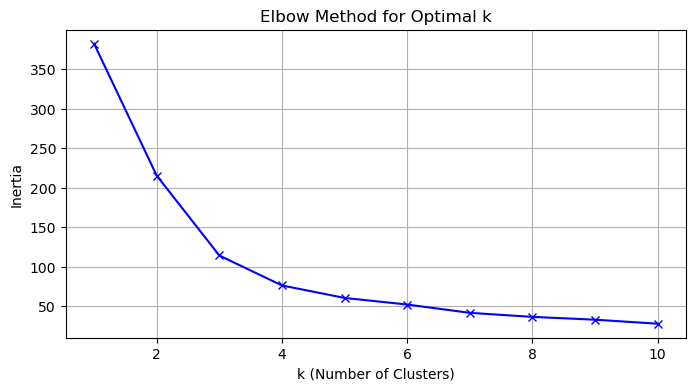

In [206]:
#Determine Optimal K (Elbow Method Plot)
inertia = []
range_k = range(1, 11)
for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range_k, inertia, 'bx-')
plt.xlabel('k (Number of Clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True);



In [210]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [216]:
labelledData['cluster_labels']=cluster_labels

C:\Users\DELL\AppData\Local\Temp\ipykernel_10900\2258208920.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelledData['cluster_labels']=cluster_labels


In [218]:
labelledData

,Country,GDP per capita $,Under-five mortality rate %,cluster_labels
11,Afghanistan,2967.69,7.24,2
13,Afghanistan,2958.79,7.00,2
15,Afghanistan,2953.00,6.76,2
25,Afghanistan,2902.39,6.54,2
26,Afghanistan,2927.24,6.33,2
...,...,...,...,...
16830,Zimbabwe,4993.84,5.11,1
16831,Zimbabwe,4527.72,5.01,1
16832,Zimbabwe,4827.09,4.76,1
16833,Zimbabwe,5036.76,4.60,1


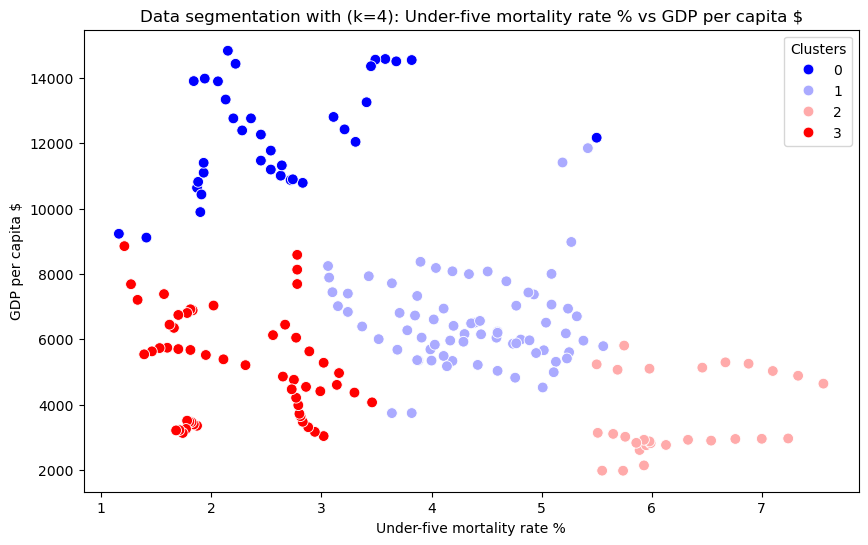

In [235]:

plt.figure(figsize=(10, 6))
sns.scatterplot(data=labelledData, x='Under-five mortality rate %', y='GDP per capita $', hue='cluster_labels', palette='bwr', s=60)
plt.title(f'Data segmentation with (k={optimal_k}): Under-five mortality rate % vs GDP per capita $')
plt.xlabel('Under-five mortality rate %')
plt.ylabel('GDP per capita $')
plt.legend(title='Clusters');
